# Week 4 Lab — Online Learning & Stream Evaluation

**Data Stream Mining — NOVA IMS**  
**LU3.1 — Classification in Data Streams**  
**Estimated laboratory time: 1h15**

> ## Big Question
> **How do we evaluate a model when the dataset never ends?**

Last week we used windows to decide **which part of the past to remember**. This week we ask a different question: when predictions arrive continuously, **how do we know whether a model is still working?**

### Today we will build

`chronological stream → predict → evaluate → learn → evolving metrics`

### Learning objectives

By the end of the lab, you should be able to:
- explain why a random train/test split is not the natural evaluation protocol for an endless temporal stream;
- implement the **test-then-train / prequential** order;
- maintain Accuracy, Macro-F1 and a confusion matrix incrementally;
- distinguish **cumulative** from **window-based** performance;
- compare a familiar frozen batch classifier with simple online learners under the **same past and the same future**;
- explain why predicting one observation at a time does **not** automatically make a model online;
- reason about predictive performance together with processing cost.

> **Central rule:** **The future must never train the past.**

## 0. Setup & framing — ~7 min

The laboratory is deliberately **offline and deterministic**. We generate a weather-like two-city stream so that every group sees the same chronology and the same controlled change in the data profile.

The controlled change is only a teaching device to make evolving performance visible. We are **not** doing concept-drift detection yet.

We will separate:

- **model state** — what the learner needs to predict and update;
- **evaluation state** — what the evaluator needs to measure performance;
- **visualization history** — values we temporarily store only so we can draw teaching plots.

The challenge after class applies the same ideas to real Open-Meteo data.

In [1]:
from __future__ import annotations

from collections import Counter, deque
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

FEATURES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
]
LABELS = ["Lisbon", "Porto"]
EVALUATION_WINDOW = 100

print("Environment ready.")

Environment ready.


### From batch evaluation to a stream

The familiar batch pattern is:

```text
dataset
   ↓
train/test split
   ↓
fit once
   ↓
predict test set
   ↓
one final score
```

A stream is different:

```text
x₁ → x₂ → x₃ → x₄ → ... → xₜ → ...
```

There may be no natural “final test set”, and the model itself may keep changing while the stream continues.

> **Evaluation can no longer be only an event at the end.**

## 1. A chronological two-city classification stream — ~8 min

We create hourly weather-like observations for two synthetic city profiles. Each timestamp produces one observation for **Lisbon** and one for **Porto**.

After part of the stream, the profiles change gradually enough to make temporal monitoring useful. Again: this is a **controlled teaching stream**, not a claim about the real cities.

In [2]:
def make_two_city_stream(n_timestamps=480, seed=42, profile_change_at=280):
    rng = np.random.default_rng(seed)
    timestamps = pd.date_range("2026-02-01", periods=n_timestamps, freq="h")
    rows = []

    for i, timestamp in enumerate(timestamps):
        daily = np.sin(2 * np.pi * i / 24)
        daily_cos = np.cos(2 * np.pi * i / 24)
        slow = np.sin(2 * np.pi * i / (24 * 9))
        after_change = i >= profile_change_at

        for city in LABELS:
            if city == "Lisbon":
                temperature = 22 + 4.0 * daily + 0.7 * slow + rng.normal(0, 1.0)
                humidity = 58 - 10.0 * daily + rng.normal(0, 3.0)
                wind = 12 + 2.5 * daily_cos + rng.normal(0, 1.4)
                rain_probability = 0.10 + 0.05 * (1 - daily) / 2
                rain_scale = 0.8
                if after_change:
                    temperature -= 3.2
                    humidity += 10.0
                    wind -= 2.1
            else:
                temperature = 18 + 3.2 * daily + 0.4 * slow + rng.normal(0, 1.0)
                humidity = 72 - 8.0 * daily + rng.normal(0, 3.0)
                wind = 8.5 + 2.0 * daily_cos + rng.normal(0, 1.4)
                rain_probability = 0.18 + 0.07 * (1 - daily) / 2
                rain_scale = 1.1
                if after_change:
                    temperature += 3.2
                    humidity -= 10.0
                    wind += 2.1

            precipitation = (
                0.0
                if rng.random() > rain_probability
                else rng.gamma(shape=1.2, scale=rain_scale)
            )

            rows.append({
                "timestamp": timestamp,
                "city": city,
                "temperature_2m": temperature,
                "relative_humidity_2m": humidity,
                "precipitation": precipitation,
                "wind_speed_10m": max(0.0, wind),
                "profile": "after" if after_change else "before",
            })

    return pd.DataFrame(rows), timestamps[profile_change_at]


stream_df, PROFILE_CHANGE_TIME = make_two_city_stream()
stream_df.head(6)

,timestamp,city,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,profile
0,2026-02-01 00:00:00,Lisbon,22.304717,54.880048,0.0,15.550632,before
1,2026-02-01 00:00:00,Porto,16.048965,68.093461,0.0,10.678977,before
2,2026-02-01 01:00:00,Lisbon,23.038834,52.852678,0.0,15.645972,before
3,2026-02-01 01:00:00,Porto,18.905886,73.311171,0.0,11.086365,before
4,2026-02-01 02:00:00,Lisbon,24.409452,50.123352,0.0,15.394894,before
5,2026-02-01 02:00:00,Porto,19.438396,65.957211,0.0,11.943609,before


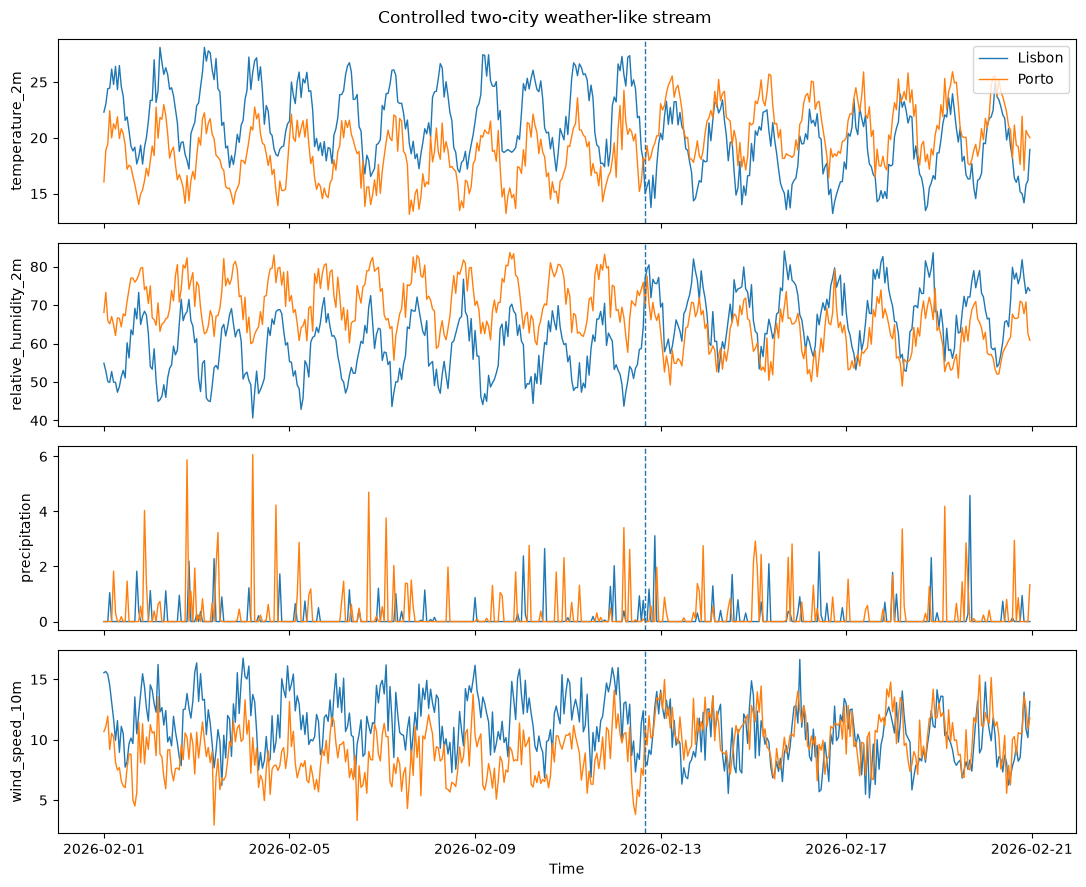

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, feature in zip(axes, FEATURES):
    for city in LABELS:
        part = stream_df[stream_df["city"] == city]
        ax.plot(part["timestamp"], part[feature], linewidth=1, label=city)
    ax.axvline(PROFILE_CHANGE_TIME, linestyle="--", linewidth=1)
    ax.set_ylabel(feature)

axes[0].legend()
axes[-1].set_xlabel("Time")
fig.suptitle("Controlled two-city weather-like stream")
fig.tight_layout()
plt.show()

### Think before coding

Suppose we want to classify the city from the current meteorological observation.

At timestamp `t`, what information is legitimately available to the model?

- observations from the past: **yes**;
- the current feature vector `x_t`: **yes**;
- the current true city label `y_t` before prediction: **no**;
- any future observation: **no**.

That temporal ordering is the foundation of this week's laboratory.

## 2. Shared warm-up and a familiar frozen classifier — ~8 min

For a fair comparison, every learner receives the **same initial past**.

We reserve the first 25% of timestamps as a shared warm-up period. After that point, evaluation begins.

The first model is deliberately familiar:

> **OFFLINE / BATCH MODEL — Logistic Regression**

It is fitted once during warm-up and then **frozen**. It can still predict one observation at a time, but it cannot incorporate new labels unless we rebuild/refit it.

In [4]:
unique_times = stream_df["timestamp"].drop_duplicates().sort_values().to_list()
warmup_cut = int(0.25 * len(unique_times))
EVALUATION_START = unique_times[warmup_cut]

warmup_df = stream_df[stream_df["timestamp"] < EVALUATION_START].copy()
evaluation_df = stream_df[stream_df["timestamp"] >= EVALUATION_START].copy()

# One common scaler, fitted only on the shared past.
scaler = StandardScaler()
X_warm = scaler.fit_transform(warmup_df[FEATURES].to_numpy())
y_warm = warmup_df["city"].to_numpy()

frozen_logistic = LogisticRegression(max_iter=1000, random_state=SEED)
frozen_logistic.fit(X_warm, y_warm)

print(f"Warm-up observations: {len(warmup_df):,}")
print(f"Evaluation observations: {len(evaluation_df):,}")
print(f"Evaluation starts at: {EVALUATION_START}")
print(f"Controlled profile change at: {PROFILE_CHANGE_TIME}")

Warm-up observations: 240
Evaluation observations: 720
Evaluation starts at: 2026-02-06 00:00:00
Controlled profile change at: 2026-02-12 16:00:00


In [5]:
preview = evaluation_df.head(6).copy()
X_preview = scaler.transform(preview[FEATURES].to_numpy())
preview["frozen_prediction"] = frozen_logistic.predict(X_preview)
preview[["timestamp", "city", "frozen_prediction"] + FEATURES]

,timestamp,city,frozen_prediction,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
240,2026-02-06 00:00:00,Lisbon,Lisbon,20.805794,60.921682,0.0,15.477993
241,2026-02-06 00:00:00,Porto,Porto,17.100868,69.422382,0.0,9.747272
242,2026-02-06 01:00:00,Lisbon,Lisbon,21.821207,56.724346,0.0,12.676357
243,2026-02-06 01:00:00,Porto,Porto,18.790186,77.264838,0.0,8.503610
244,2026-02-06 02:00:00,Lisbon,Lisbon,23.872587,54.233516,0.0,14.330751
245,2026-02-06 02:00:00,Porto,Porto,19.287883,72.362151,0.0,9.592991


### Exercise 1 — Is this model online?

The frozen Logistic Regression is receiving **one observation at a time** during evaluation.

Does that make it an online learner?

<details>
<summary><strong>Reveal discussion</strong></summary>

No. Prediction granularity and learning regime are different ideas.

The model can call `predict(...)` for one observation, but its parameters remain unchanged after the warm-up. An online learner must be able to **incorporate newly revealed labelled information without rebuilding the full model from scratch**.

</details>

## 3. Build an incremental evaluator — ~10 min

We now make **evaluation itself** a streaming computation.

Each evaluated prediction contributes only one pair:

```text
(y_true, y_pred)
```

From that pair we can update a compact state:

```text
old metric state + new prediction outcome → new metric state
```

This is the same computational idea we have used since Week 2.

In [6]:
class OnlineConfusionMatrix:
    def __init__(self, labels):
        self.labels = list(labels)
        self.index = {label: i for i, label in enumerate(self.labels)}
        self.matrix = np.zeros((len(self.labels), len(self.labels)), dtype=int)

    def update(self, y_true, y_pred):
        self.matrix[self.index[y_true], self.index[y_pred]] += 1

    def remove(self, y_true, y_pred):
        self.matrix[self.index[y_true], self.index[y_pred]] -= 1

    @property
    def total(self):
        return int(self.matrix.sum())

    @property
    def correct(self):
        return int(np.trace(self.matrix))

    def accuracy(self):
        return self.correct / self.total if self.total else np.nan

    def precision(self, label):
        i = self.index[label]
        tp = self.matrix[i, i]
        predicted = self.matrix[:, i].sum()
        return float(tp / predicted) if predicted else 0.0

    def recall(self, label):
        i = self.index[label]
        tp = self.matrix[i, i]
        actual = self.matrix[i, :].sum()
        return float(tp / actual) if actual else 0.0

    def f1(self, label):
        p = self.precision(label)
        r = self.recall(label)
        return 2 * p * r / (p + r) if (p + r) else 0.0

    def macro_f1(self):
        return float(np.mean([self.f1(label) for label in self.labels])) if self.total else np.nan

In [7]:
class StreamingEvaluator:
    def __init__(self, labels, window_size=100):
        self.cumulative = OnlineConfusionMatrix(labels)
        self.recent = OnlineConfusionMatrix(labels)
        self.window_size = int(window_size)
        self.recent_pairs = deque()
        self.observations_seen = 0
        self.predictions_evaluated = 0
        self.cold_starts = 0

    def observe(self, y_true, y_pred):
        self.observations_seen += 1
        if y_pred is None:
            self.cold_starts += 1
            return self.snapshot()

        self.predictions_evaluated += 1
        self.cumulative.update(y_true, y_pred)

        if len(self.recent_pairs) == self.window_size:
            old_true, old_pred = self.recent_pairs.popleft()
            self.recent.remove(old_true, old_pred)

        self.recent_pairs.append((y_true, y_pred))
        self.recent.update(y_true, y_pred)
        return self.snapshot()

    def snapshot(self):
        return {
            "cumulative_accuracy": self.cumulative.accuracy(),
            "window_accuracy": self.recent.accuracy(),
            "cumulative_macro_f1": self.cumulative.macro_f1(),
            "window_macro_f1": self.recent.macro_f1(),
        }

In [8]:
# Tiny sanity check: one error expires after the fourth observation.
ev = StreamingEvaluator(LABELS, window_size=3)
for pair in [
    ("Lisbon", "Porto"),
    ("Lisbon", "Lisbon"),
    ("Porto", "Porto"),
    ("Porto", "Porto"),
]:
    print(pair, ev.observe(*pair))

print("Recent confusion matrix after eviction:")
print(ev.recent.matrix)

('Lisbon', 'Porto') {'cumulative_accuracy': 0.0, 'window_accuracy': 0.0, 'cumulative_macro_f1': 0.0, 'window_macro_f1': 0.0}
('Lisbon', 'Lisbon') {'cumulative_accuracy': 0.5, 'window_accuracy': 0.5, 'cumulative_macro_f1': 0.3333333333333333, 'window_macro_f1': 0.3333333333333333}
('Porto', 'Porto') {'cumulative_accuracy': 0.6666666666666666, 'window_accuracy': 0.6666666666666666, 'cumulative_macro_f1': 0.6666666666666666, 'window_macro_f1': 0.6666666666666666}
('Porto', 'Porto') {'cumulative_accuracy': 0.75, 'window_accuracy': 1.0, 'cumulative_macro_f1': 0.7333333333333334, 'window_macro_f1': 1.0}
Recent confusion matrix after eviction:
[[1 0]
 [0 2]]


### Exercise 2 — What does the evaluator remember?

After processing one million predictions, how much raw prediction history does the **cumulative** confusion matrix need to retain?

And how many `(y_true, y_pred)` pairs does the **windowed** evaluator need when `window_size = 100`?

<details>
<summary><strong>Reveal answer</strong></summary>

The cumulative confusion matrix needs only its fixed matrix of counts: its state does **not** grow with the number of predictions.

The recent evaluator stores at most **100 pairs**, because it must know which old contribution to remove when the window slides.

This is Week 3 again: **windowing is controlled forgetting**, now applied to model errors rather than raw sensor values.

</details>

## 4. Test-then-train with an Online Majority baseline — ~7 min

Our first online learner is intentionally simple.

**Online Majority** stores only class counts:

```text
Lisbon:  ...
Porto:   ...
```

Its prediction is the most frequent class seen so far. After the true label is revealed, the counts are updated.

The central protocol is:

> **PREDICT → EVALUATE → LEARN**

In [9]:
class OnlineMajorityClassifier:
    def __init__(self):
        self.counts = Counter()

    def predict_one(self, x):
        if not self.counts:
            return None
        # Deterministic tie-breaking by label order.
        return max(LABELS, key=lambda label: (self.counts[label], -LABELS.index(label)))

    def learn_one(self, x, y):
        self.counts[y] += 1
        return self


class FrozenSklearnClassifier:
    def __init__(self, model):
        self.model = model

    def predict_one(self, x):
        return self.model.predict(np.asarray(x).reshape(1, -1))[0]

    def learn_one(self, x, y):
        return self  # deliberately frozen


def vectorize_row(row):
    raw = np.array([getattr(row, feature) for feature in FEATURES], dtype=float)
    return scaler.transform(raw.reshape(1, -1))[0]


def warm_up_online(model, warmup):
    for row in warmup.itertuples(index=False):
        model.learn_one(vectorize_row(row), row.city)
    return model


def evaluate_model(model, data, *, learn):
    evaluator = StreamingEvaluator(LABELS, window_size=EVALUATION_WINDOW)
    history = []
    predict_seconds = 0.0
    update_seconds = 0.0

    for row in data.itertuples(index=False):
        x = vectorize_row(row)
        y = row.city

        t0 = time.perf_counter()
        y_pred = model.predict_one(x)
        predict_seconds += time.perf_counter() - t0

        snapshot = evaluator.observe(y, y_pred)  # TEST / EVALUATE FIRST

        if learn:
            t0 = time.perf_counter()
            model.learn_one(x, y)                 # TRAIN SECOND
            update_seconds += time.perf_counter() - t0

        history.append({
            "timestamp": row.timestamp,
            "y_true": y,
            "y_pred": y_pred,
            **snapshot,
        })

    return evaluator, pd.DataFrame(history), predict_seconds, update_seconds

In [10]:
majority = warm_up_online(OnlineMajorityClassifier(), warmup_df)
majority_warmup_counts = dict(majority.counts)
frozen = FrozenSklearnClassifier(frozen_logistic)

majority_eval, majority_hist, majority_pred_s, majority_update_s = evaluate_model(
    majority, evaluation_df, learn=True
)
frozen_eval, frozen_hist, frozen_pred_s, frozen_update_s = evaluate_model(
    frozen, evaluation_df, learn=False
)

print("Online Majority counts after shared warm-up:", majority_warmup_counts)
print("Final Majority accuracy:", round(majority_eval.cumulative.accuracy(), 3))
print("Final Frozen Logistic accuracy:", round(frozen_eval.cumulative.accuracy(), 3))

Online Majority counts after shared warm-up: {'Lisbon': 120, 'Porto': 120}
Final Majority accuracy: 0.5
Final Frozen Logistic accuracy: 0.599


### Connection to Week 2

The Majority classifier is already a genuine online learner:

```text
old class counts + new label → new class counts
```

It is simple, but it demonstrates the defining property: **the model changes incrementally as new labelled observations arrive**.

## 5. Online Logistic Regression — ~10 min

Now we keep the **logistic decision family**, but change the learning regime.

The batch model used `fit(...)` once during warm-up.

The online version uses `partial_fit(...)` repeatedly, updating its parameters after each evaluated observation.

> **Same past. Same future. Similar predictive family. Different learning regime.**

In [11]:
class OnlineLogisticRegression:
    def __init__(self, labels, seed=42):
        self.labels = np.array(labels)
        self.model = SGDClassifier(
            loss="log_loss",
            alpha=0.0001,
            learning_rate="constant",
            eta0=0.10,
            random_state=seed,
        )
        self.initialized = False

    def predict_one(self, x):
        if not self.initialized:
            return None
        return self.model.predict(np.asarray(x).reshape(1, -1))[0]

    def learn_one(self, x, y):
        X = np.asarray(x).reshape(1, -1)
        y_arr = np.array([y])
        if not self.initialized:
            self.model.partial_fit(X, y_arr, classes=self.labels)
            self.initialized = True
        else:
            self.model.partial_fit(X, y_arr)
        return self


online_logistic = warm_up_online(OnlineLogisticRegression(LABELS, seed=SEED), warmup_df)
online_log_eval, online_log_hist, online_log_pred_s, online_log_update_s = evaluate_model(
    online_logistic, evaluation_df, learn=True
)

print("Frozen Logistic final accuracy:", round(frozen_eval.cumulative.accuracy(), 3))
print("Online Logistic final accuracy:", round(online_log_eval.cumulative.accuracy(), 3))
print("Online Logistic recent accuracy:", round(online_log_eval.recent.accuracy(), 3))

Frozen Logistic final accuracy: 0.599
Online Logistic final accuracy: 0.725
Online Logistic recent accuracy: 0.62


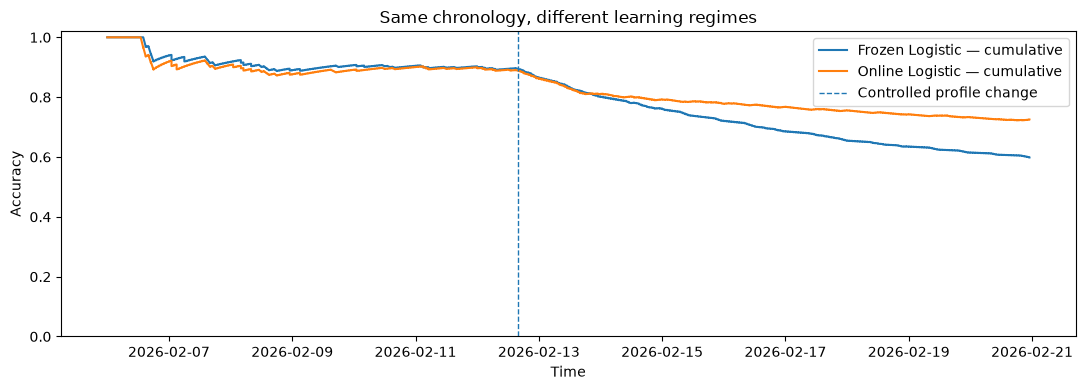

In [12]:
plt.figure(figsize=(11, 4))
plt.plot(frozen_hist["timestamp"], frozen_hist["cumulative_accuracy"], label="Frozen Logistic — cumulative")
plt.plot(online_log_hist["timestamp"], online_log_hist["cumulative_accuracy"], label="Online Logistic — cumulative")
plt.axvline(PROFILE_CHANGE_TIME, linestyle="--", linewidth=1, label="Controlled profile change")
plt.ylim(0, 1.02)
plt.ylabel("Accuracy")
plt.xlabel("Time")
plt.title("Same chronology, different learning regimes")
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 3 — Predict before running

After the controlled profile change, which model should react more naturally?

- the frozen Logistic Regression;
- the Online Logistic Regression.

Why?

<details>
<summary><strong>Reveal discussion</strong></summary>

The online model has a mechanism to incorporate newly revealed labelled observations after they have been evaluated. The frozen model does not.

This does **not** mean an online model is guaranteed to have higher accuracy on every stream. It means the online model has the ability to **continue updating** as evidence arrives.

</details>

## 6. A second simple online learner: Gaussian Naive Bayes — ~8 min

We now add another incremental classifier.

Gaussian Naive Bayes maintains compact class-specific statistics and can update them as observations arrive. It gives us a second example of true online learning without introducing advanced stream trees or ensembles yet.

In this notebook we use `partial_fit(...)` so the lab remains self-contained with scikit-learn.

Conceptually, the loop remains identical:

```text
predict_one(x)
→ evaluate
→ learn_one(x, y)
```

In [13]:
class OnlineGaussianNaiveBayes:
    def __init__(self, labels):
        self.labels = np.array(labels)
        self.model = GaussianNB()
        self.initialized = False

    def predict_one(self, x):
        if not self.initialized:
            return None
        return self.model.predict(np.asarray(x).reshape(1, -1))[0]

    def learn_one(self, x, y):
        X = np.asarray(x).reshape(1, -1)
        y_arr = np.array([y])
        if not self.initialized:
            self.model.partial_fit(X, y_arr, classes=self.labels)
            self.initialized = True
        else:
            self.model.partial_fit(X, y_arr)
        return self


gnb = warm_up_online(OnlineGaussianNaiveBayes(LABELS), warmup_df)
gnb_eval, gnb_hist, gnb_pred_s, gnb_update_s = evaluate_model(
    gnb, evaluation_df, learn=True
)

summary = pd.DataFrame([
    {"model": "Online Majority", "accuracy": majority_eval.cumulative.accuracy(), "macro_f1": majority_eval.cumulative.macro_f1()},
    {"model": "Frozen Logistic (OFFLINE)", "accuracy": frozen_eval.cumulative.accuracy(), "macro_f1": frozen_eval.cumulative.macro_f1()},
    {"model": "Online Logistic Regression", "accuracy": online_log_eval.cumulative.accuracy(), "macro_f1": online_log_eval.cumulative.macro_f1()},
    {"model": "Online Gaussian Naive Bayes", "accuracy": gnb_eval.cumulative.accuracy(), "macro_f1": gnb_eval.cumulative.macro_f1()},
]).set_index("model")

summary.round(3)

,accuracy,macro_f1
model,,
Online Majority,0.500,0.333
Frozen Logistic (OFFLINE),0.599,0.598
Online Logistic Regression,0.725,0.725
Online Gaussian Naive Bayes,0.603,0.603


## 7. Cumulative vs recent performance — ~12 min

Cumulative metrics answer:

> **How has the model performed throughout its evaluated history?**

Window-based metrics answer:

> **How is the model performing recently?**

These are different questions.

A cumulative metric remembers every past error. A window metric deliberately forgets expired prediction outcomes.

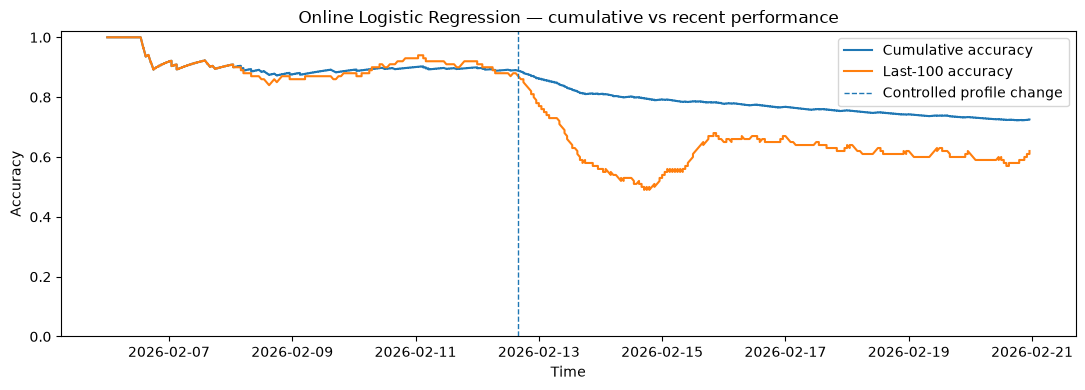

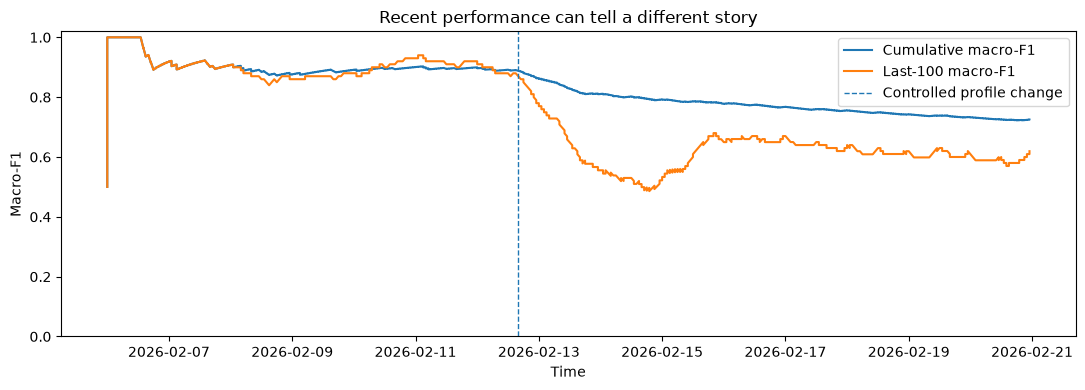

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(online_log_hist["timestamp"], online_log_hist["cumulative_accuracy"], label="Cumulative accuracy")
ax.plot(online_log_hist["timestamp"], online_log_hist["window_accuracy"], label=f"Last-{EVALUATION_WINDOW} accuracy")
ax.axvline(PROFILE_CHANGE_TIME, linestyle="--", linewidth=1, label="Controlled profile change")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Time")
ax.set_ylabel("Accuracy")
ax.set_title("Online Logistic Regression — cumulative vs recent performance")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(online_log_hist["timestamp"], online_log_hist["cumulative_macro_f1"], label="Cumulative macro-F1")
ax.plot(online_log_hist["timestamp"], online_log_hist["window_macro_f1"], label=f"Last-{EVALUATION_WINDOW} macro-F1")
ax.axvline(PROFILE_CHANGE_TIME, linestyle="--", linewidth=1, label="Controlled profile change")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Time")
ax.set_ylabel("Macro-F1")
ax.set_title("Recent performance can tell a different story")
ax.legend()
plt.tight_layout()
plt.show()

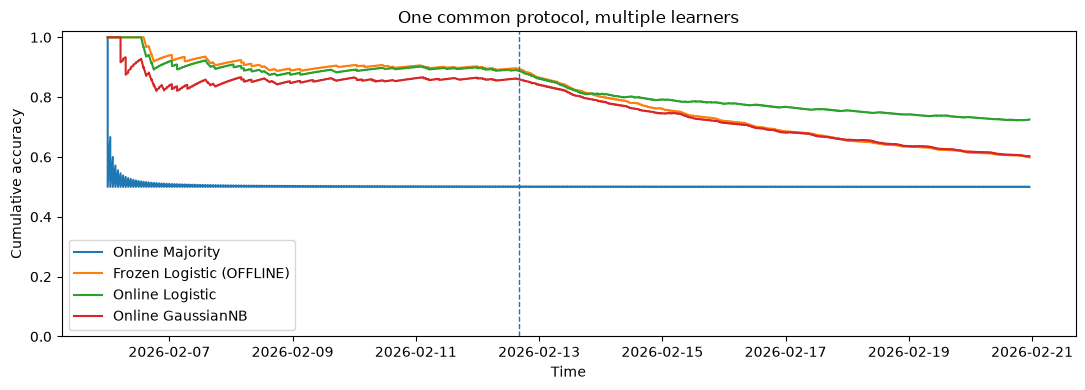

In [15]:
plt.figure(figsize=(11, 4))
plt.plot(majority_hist["timestamp"], majority_hist["cumulative_accuracy"], label="Online Majority")
plt.plot(frozen_hist["timestamp"], frozen_hist["cumulative_accuracy"], label="Frozen Logistic (OFFLINE)")
plt.plot(online_log_hist["timestamp"], online_log_hist["cumulative_accuracy"], label="Online Logistic")
plt.plot(gnb_hist["timestamp"], gnb_hist["cumulative_accuracy"], label="Online GaussianNB")
plt.axvline(PROFILE_CHANGE_TIME, linestyle="--", linewidth=1)
plt.ylim(0, 1.02)
plt.xlabel("Time")
plt.ylabel("Cumulative accuracy")
plt.title("One common protocol, multiple learners")
plt.legend()
plt.tight_layout()
plt.show()

### Discuss

Look at the controlled profile change.

- Which curve reacts first?
- Which metric is more useful for describing **performance now**?
- Why can cumulative performance remain relatively smooth even when recent behaviour changes?

> **Cumulative metrics remember everything. Windowed metrics remember what matters now.**

### Exercise 4 — Change the evaluator's memory

Change:

```python
EVALUATION_WINDOW = 100
```

to `30` or `200`, then rerun the evaluator/model sections.

Predict before running:

- Which window should react faster?
- Which one should be more stable?

<details>
<summary><strong>Reveal answer</strong></summary>

A smaller window generally reacts faster because old outcomes disappear sooner, but its metric is also more variable. A larger window is more stable but slower to reflect recent changes.

This is the same **reactivity–stability trade-off** we saw in Week 3.

</details>

## 8. Online confusion matrix — ~5 min

Accuracy alone does not tell us **which class** is being recognized well.

Because the confusion matrix is maintained incrementally, we can inspect current accumulated behaviour without storing every prediction.

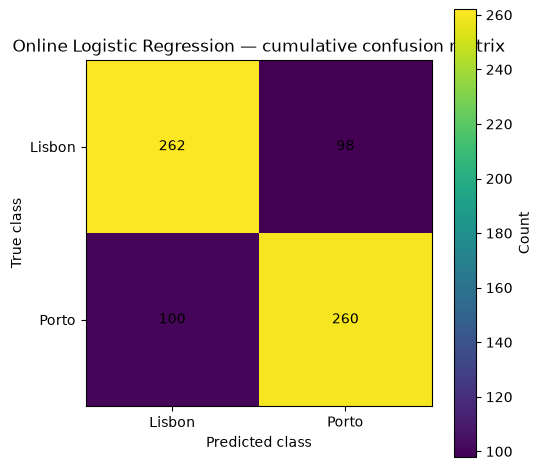

 Lisbon | precision=0.724 recall=0.728 F1=0.726
  Porto | precision=0.726 recall=0.722 F1=0.724


In [16]:
cm = online_log_eval.cumulative.matrix

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm)
ax.set_xticks(range(len(LABELS)), LABELS)
ax.set_yticks(range(len(LABELS)), LABELS)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Online Logistic Regression — cumulative confusion matrix")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

for label in LABELS:
    print(
        f"{label:>7} | precision={online_log_eval.cumulative.precision(label):.3f} "
        f"recall={online_log_eval.cumulative.recall(label):.3f} "
        f"F1={online_log_eval.cumulative.f1(label):.3f}"
    )

## 9. Computational performance — ~5 min

A stream has a time budget as well as a predictive objective.

We recorded prediction and update time during the same evaluation pass. These measurements are **environment dependent**; use them to reason about the architecture, not to make universal speed claims.

Also note the evaluator's memory:

- cumulative confusion matrix: fixed number of counters;
- recent evaluator: at most `EVALUATION_WINDOW` prediction pairs;
- full visualization history: grows because **we chose to record it for teaching plots**.

,prediction_ms/event,update_ms/event
model,,
Online Majority,0.0033,0.0012
Frozen Logistic,0.2170,0.0000
Online Logistic,0.2511,0.8769
Online GaussianNB,0.2226,0.5027


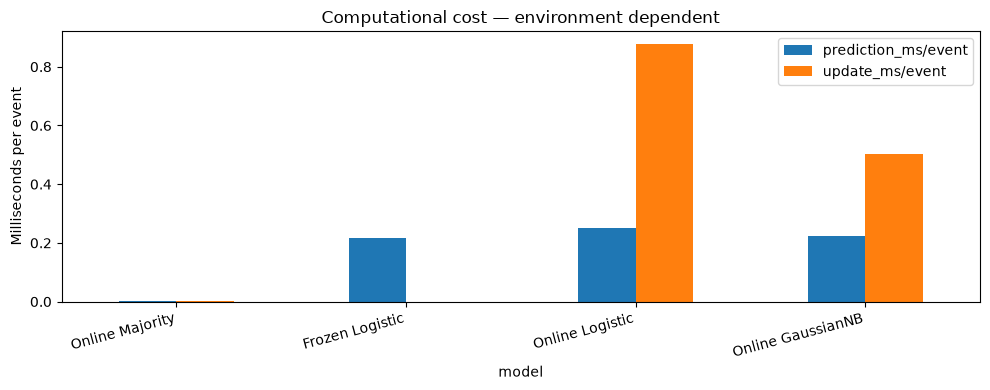

Cumulative evaluator counters: 4
Recent prediction pairs retained: 100
Visualization-history rows retained for teaching: 720


In [17]:
performance = pd.DataFrame([
    {"model": "Online Majority", "prediction_ms/event": 1e3 * majority_pred_s / len(evaluation_df), "update_ms/event": 1e3 * majority_update_s / len(evaluation_df)},
    {"model": "Frozen Logistic", "prediction_ms/event": 1e3 * frozen_pred_s / len(evaluation_df), "update_ms/event": 0.0},
    {"model": "Online Logistic", "prediction_ms/event": 1e3 * online_log_pred_s / len(evaluation_df), "update_ms/event": 1e3 * online_log_update_s / len(evaluation_df)},
    {"model": "Online GaussianNB", "prediction_ms/event": 1e3 * gnb_pred_s / len(evaluation_df), "update_ms/event": 1e3 * gnb_update_s / len(evaluation_df)},
]).set_index("model")

display(performance.round(4))

ax = performance.plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("Milliseconds per event")
ax.set_title("Computational cost — environment dependent")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("Cumulative evaluator counters:", online_log_eval.cumulative.matrix.size)
print("Recent prediction pairs retained:", len(online_log_eval.recent_pairs))
print("Visualization-history rows retained for teaching:", len(online_log_hist))

## 10. Reflection & Week 5 bridge — ~5 min

Before leaving the lab, make sure you can answer these questions without looking at the code:

1. Why can a frozen batch model predict one observation at a time without being an online learner?
2. Why must the current prediction be evaluated **before** the current true label is used for learning?
3. What does a cumulative metric remember that a sliding metric deliberately forgets?
4. Why did all models receive the same warm-up period?
5. Why can Accuracy and Macro-F1 tell different stories?
6. Which parts of this notebook require bounded memory, and which parts grow only because we chose to retain visualization history?

### The Week 4 loop

```text
OBSERVATION
    ↓
PREDICT
    ↓
REVEAL TRUTH
    ↓
EVALUATE
    ↓
UPDATE METRIC STATE
    ↓
UPDATE MODEL STATE
    ↓
NEXT OBSERVATION
```

> **Online evaluation is a streaming algorithm too.**

### Week 5 bridge

Today the evaluation protocol was the protagonist. We used deliberately simple online learners so that the loop stayed visible.

Next week the question changes:

> **How can more powerful predictive models learn one observation at a time?**

That is where we move from **online evaluation** to a broader family of **incremental stream classifiers**.